# EDA - Domain Adaptation amb Espanya com a target

Aquest notebook analitza unicament la demanda horaria europea d'ENTSO-E. El domini objectiu es Espanya i la resta de paisos actuen com a dominis font. El notebook acaba amb un preprocessing executable que construeix `df_model` llest per modelar en memoria.

In [6]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

def find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    for candidate in candidates:
        if (candidate / "data" / "raw" / "europe" / "demand").exists():
            return candidate
    raise FileNotFoundError("No s'ha trobat data/raw/europe/demand des del directori actual.")

ROOT = find_repo_root()
DEMAND_DIR = ROOT / "data" / "raw" / "europe" / "demand"
TARGET_CODE = "ES"
SOURCE_CODES = ["BE", "DE", "FR", "GR", "IT", "NL", "PT"]
ALL_CODES = [TARGET_CODE, *SOURCE_CODES]

In [8]:
def rename_series(code: str) -> str:
    code = code.lower()

    return "target_es" if code == "es" else f"source_{code}"

def load_country_demand(code: str) -> pd.DataFrame:
    path = DEMAND_DIR / f"entsoe_demand_{code}.csv"
    df = pd.read_csv(path)
    df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"], utc=True)
    df = df.rename(columns={"demand": rename_series(code)})
    df = df[["utc_timestamp", rename_series(code)]].drop_duplicates(subset=["utc_timestamp"])
    return df.set_index("utc_timestamp").sort_index()

demand_frames = {code: load_country_demand(code) for code in ALL_CODES}
raw_demand = pd.concat(demand_frames.values(), axis=1, join="outer").sort_index()
print(f"Series carregades: {list(demand_frames)}")
print(f"Shape del concat raw: {raw_demand.shape}")
display(raw_demand.head())

Series carregades: ['ES', 'BE', 'DE', 'FR', 'GR', 'IT', 'NL', 'PT']
Shape del concat raw: (97968, 8)


,target_es,source_be,source_de,source_fr,source_gr,source_it,source_nl,source_pt
utc_timestamp,,,,,,,,
2015-01-01 00:00:00+00:00,24382.0,9551.8300,43833.0675,70929.0,5552.73,23126.0,9456.00,5340.5
2015-01-01 01:00:00+00:00,22734.0,9152.0225,42322.1125,69773.0,5226.83,21534.0,8956.75,5123.9
2015-01-01 02:00:00+00:00,21286.0,8798.7025,40965.8850,66417.0,4987.34,20219.0,8461.50,4771.1
2015-01-01 03:00:00+00:00,20264.0,8567.1000,40283.5825,64182.0,4879.48,19470.0,8156.00,4443.5
2015-01-01 04:00:00+00:00,19905.0,8487.4375,39621.6400,63859.0,4909.53,19485.0,8126.00,4234.9


In [9]:
def dominant_frequency(index: pd.DatetimeIndex) -> str:
    diffs = index.to_series().sort_values().diff().dropna()
    if diffs.empty:
        return ""
    delta = diffs.mode().iloc[0]
    minutes = int(delta.total_seconds() // 60)
    if minutes == 60:
        return "1h"
    if minutes < 60:
        return f"{minutes}min"
    return f"{minutes // 60}h"

inventory_rows = []
for code, frame in demand_frames.items():
    col = frame.columns[0]
    inventory_rows.append({
        "country": code,
        "role": "target" if code == TARGET_CODE else "source",
        "column": col,
        "rows": len(frame),
        "start": frame.index.min(),
        "end": frame.index.max(),
        "duplicates": int(frame.index.duplicated().sum()),
        "missing_ratio": round(frame[col].isna().mean(), 6),
        "dominant_frequency": dominant_frequency(frame.index),
    })

inventory_df = pd.DataFrame(inventory_rows).sort_values(["role", "country"]).reset_index(drop=True)
display(inventory_df)

,country,role,column,rows,start,end,duplicates,missing_ratio,dominant_frequency
0,BE,source,source_be,97967,2015-01-01 00:00:00+00:00,2026-03-05 22:00:00+00:00,0,0.000000,1h
1,DE,source,source_de,97967,2015-01-01 00:00:00+00:00,2026-03-05 22:00:00+00:00,0,0.000000,1h
2,FR,source,source_fr,97967,2015-01-01 00:00:00+00:00,2026-03-05 22:00:00+00:00,0,0.001194,1h
3,GR,source,source_gr,97966,2015-01-01 00:00:00+00:00,2026-03-05 21:00:00+00:00,0,0.000357,1h
4,IT,source,source_it,97967,2015-01-01 00:00:00+00:00,2026-03-05 22:00:00+00:00,0,0.000000,1h
5,NL,source,source_nl,97967,2015-01-01 00:00:00+00:00,2026-03-05 22:00:00+00:00,0,0.000000,1h
6,PT,source,source_pt,97968,2015-01-01 00:00:00+00:00,2026-03-05 23:00:00+00:00,0,0.000000,1h
7,ES,target,target_es,97967,2015-01-01 00:00:00+00:00,2026-03-05 22:00:00+00:00,0,0.000316,1h


## Control de qualitat

,country,rows,missing_ratio,dominant_frequency,duplicates
0,BE,97967,0.000000,1h,0
1,DE,97967,0.000000,1h,0
2,FR,97967,0.001194,1h,0
3,GR,97966,0.000357,1h,0
4,IT,97967,0.000000,1h,0
5,NL,97967,0.000000,1h,0
6,PT,97968,0.000000,1h,0
7,ES,97967,0.000316,1h,0


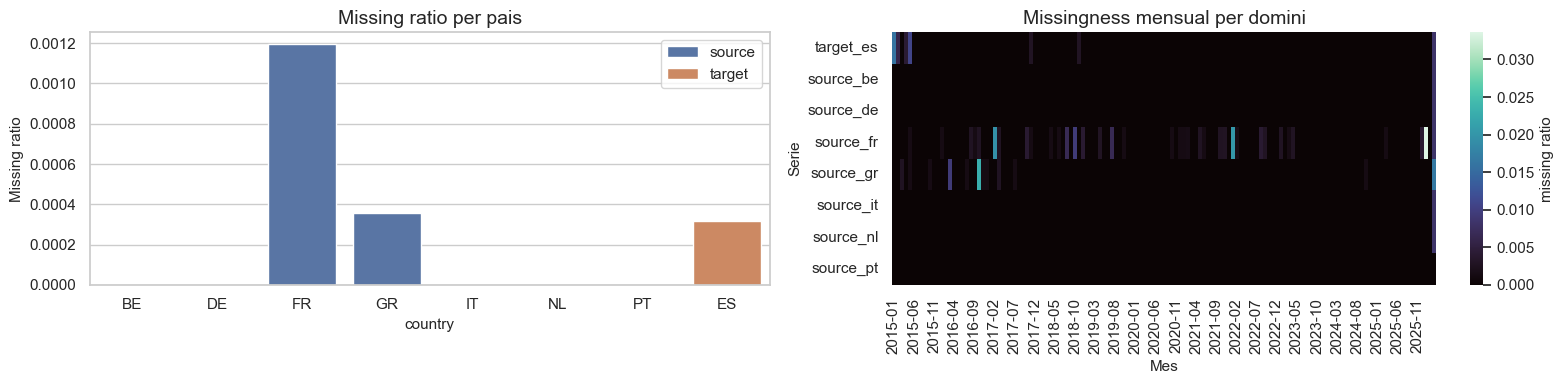

In [10]:
coverage_df = inventory_df[["country", "rows", "missing_ratio", "dominant_frequency", "duplicates"]].copy()
display(coverage_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.barplot(data=inventory_df, x="country", y="missing_ratio", hue="role", dodge=False, ax=axes[0])
axes[0].set_title("Missing ratio per pais")
axes[0].set_ylabel("Missing ratio")
axes[0].legend(loc="upper right")

monthly_missing = raw_demand.isna().groupby(raw_demand.index.to_period("M")).mean()
monthly_missing.index = monthly_missing.index.astype(str)
sns.heatmap(monthly_missing.T, cmap="mako", cbar_kws={"label": "missing ratio"}, ax=axes[1])
axes[1].set_title("Missingness mensual per domini")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Serie")
plt.tight_layout()
plt.show()

## EDA del target Espanya

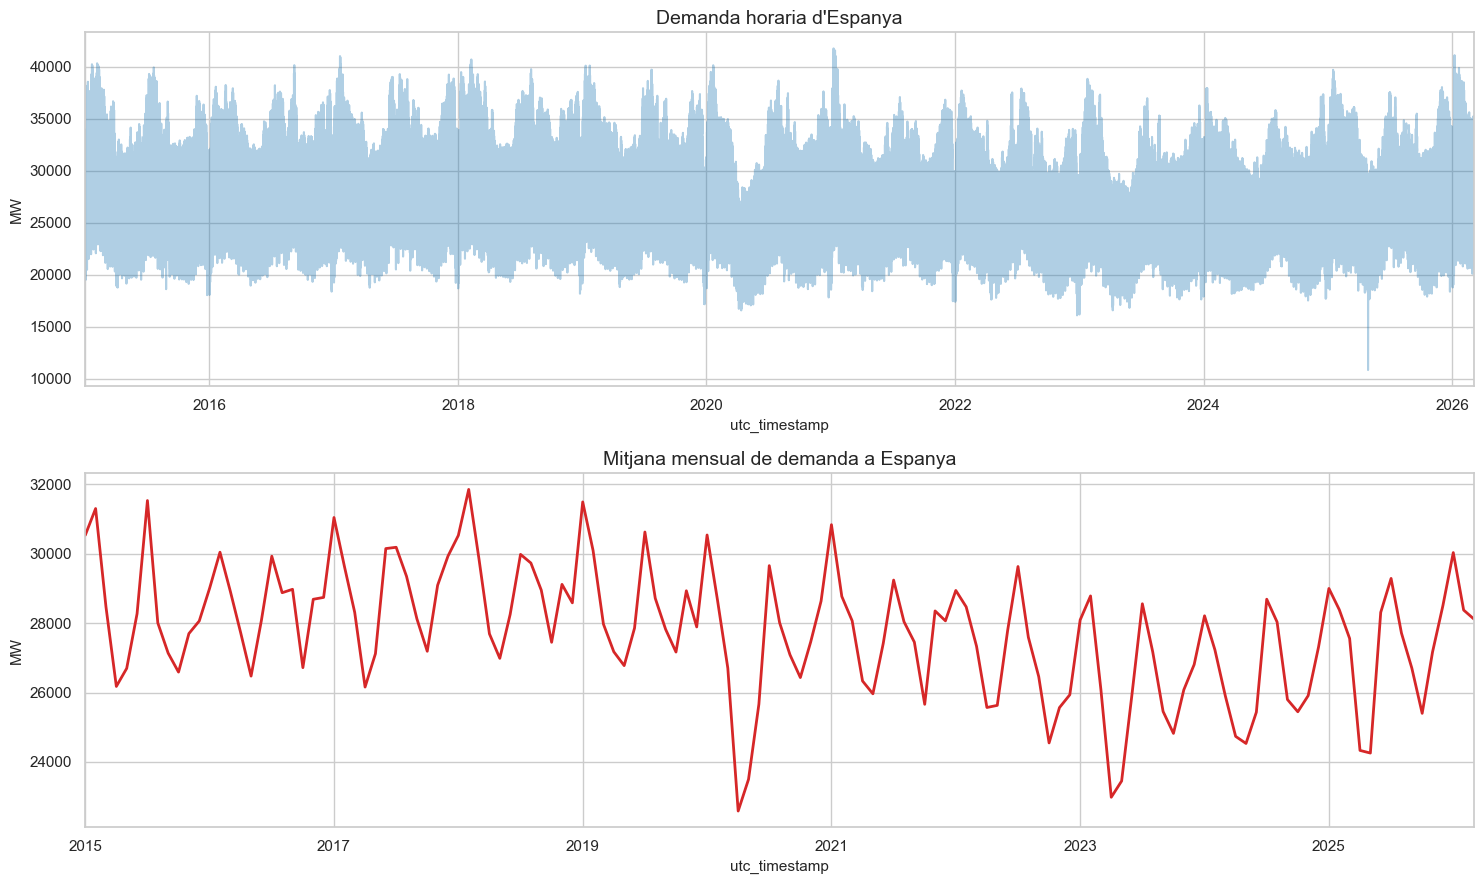

In [11]:
target_series = demand_frames[TARGET_CODE]["target_es"].copy()
target_monthly = target_series.resample("MS").mean()

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=False)
target_series.plot(ax=axes[0], alpha=0.35, color="#1f77b4")
axes[0].set_title("Demanda horaria d'Espanya")
axes[0].set_ylabel("MW")

target_monthly.plot(ax=axes[1], color="#d62728", linewidth=2)
axes[1].set_title("Mitjana mensual de demanda a Espanya")
axes[1].set_ylabel("MW")
plt.tight_layout()
plt.show()

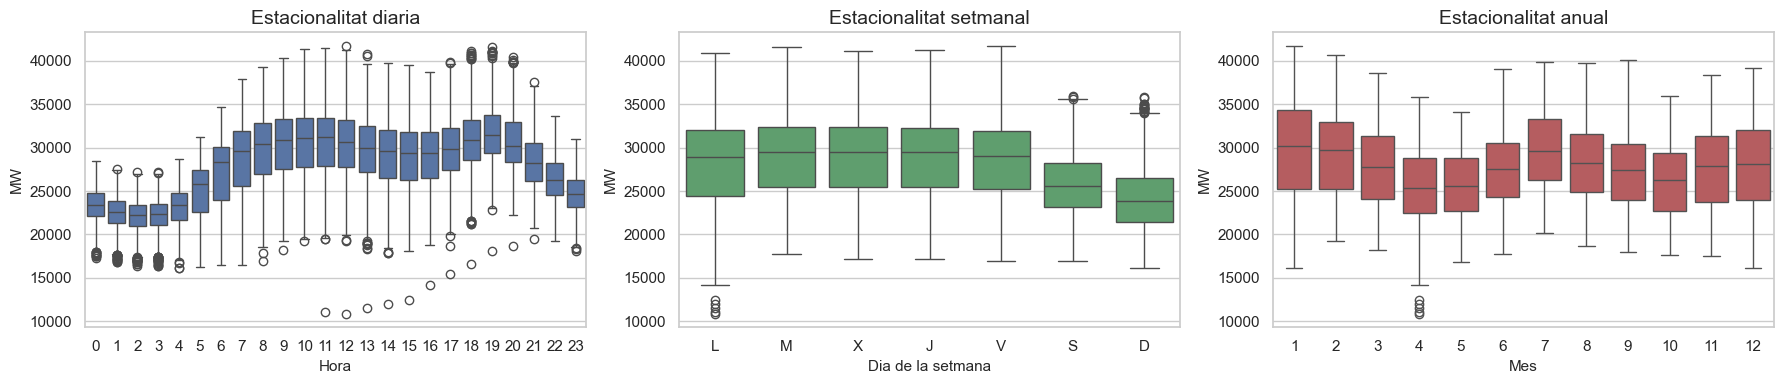

In [13]:
target_features = pd.DataFrame({"target_es": target_series})
target_features["hour"] = target_features.index.hour
target_features["dayofweek"] = target_features.index.dayofweek
target_features["month"] = target_features.index.month

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.boxplot(data=target_features, x="hour", y="target_es", color="#4c72b0", ax=axes[0])
axes[0].set_title("Estacionalitat diaria")
axes[0].set_xlabel("Hora")
axes[0].set_ylabel("MW")

sns.boxplot(data=target_features, x="dayofweek", y="target_es", color="#55a868", ax=axes[1])
axes[1].set_title("Estacionalitat setmanal")
axes[1].set_xlabel("Dia de la setmana")
axes[1].set_ylabel("MW")
axes[1].set_xticklabels(["L", "M", "X", "J", "V", "S", "D"])

sns.boxplot(data=target_features, x="month", y="target_es", color="#c44e52", ax=axes[2])
axes[2].set_title("Estacionalitat anual")
axes[2].set_xlabel("Mes")
axes[2].set_ylabel("MW")
plt.tight_layout()
plt.show()

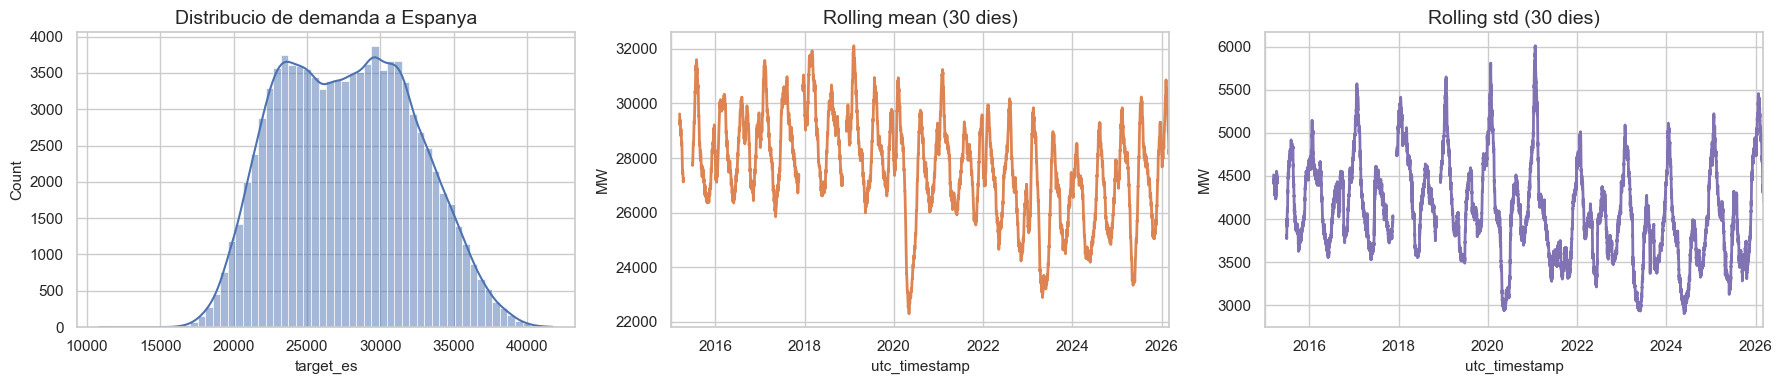

,lag,autocorrelation
0,1,0.956656
1,24,0.825748
2,168,0.901337


In [14]:
rolling_window = 24 * 30
rolling_mean = target_series.rolling(rolling_window).mean()
rolling_std = target_series.rolling(rolling_window).std()
autocorr_df = pd.DataFrame({
    "lag": [1, 24, 168],
    "autocorrelation": [target_series.autocorr(lag=lag) for lag in [1, 24, 168]],
})

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(target_series, bins=60, kde=True, ax=axes[0], color="#4c72b0")
axes[0].set_title("Distribucio de demanda a Espanya")

rolling_mean.plot(ax=axes[1], color="#dd8452", linewidth=2)
axes[1].set_title("Rolling mean (30 dies)")
axes[1].set_ylabel("MW")

rolling_std.plot(ax=axes[2], color="#8172b3", linewidth=2)
axes[2].set_title("Rolling std (30 dies)")
axes[2].set_ylabel("MW")
plt.tight_layout()
plt.show()

display(autocorr_df)

## EDA multi-domini

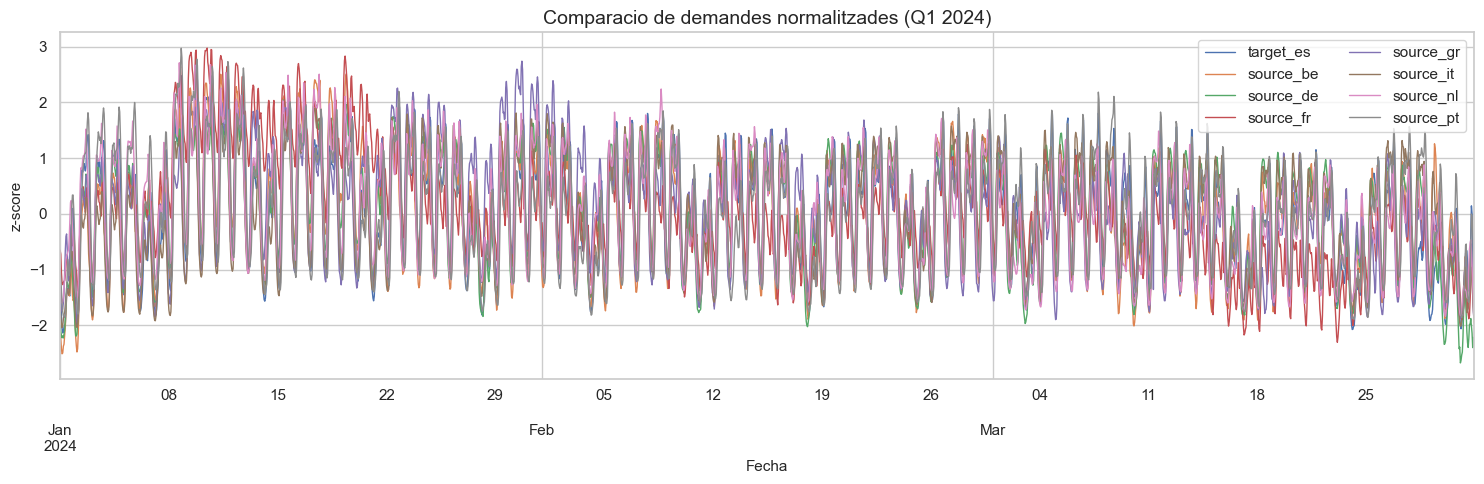

In [15]:
comparison_start = pd.Timestamp("2024-01-01", tz="UTC")
comparison_end = pd.Timestamp("2024-03-31 23:00:00", tz="UTC")
comparison_df = raw_demand.loc[comparison_start:comparison_end].copy()
comparison_z = (comparison_df - comparison_df.mean()) / comparison_df.std()

plt.figure(figsize=(15, 5))
comparison_z.plot(ax=plt.gca(), linewidth=1)
plt.title("Comparacio de demandes normalitzades (Q1 2024)")
plt.ylabel("z-score")
plt.xlabel("Fecha")
plt.legend(loc="upper right", ncol=2)
plt.tight_layout()
plt.show()

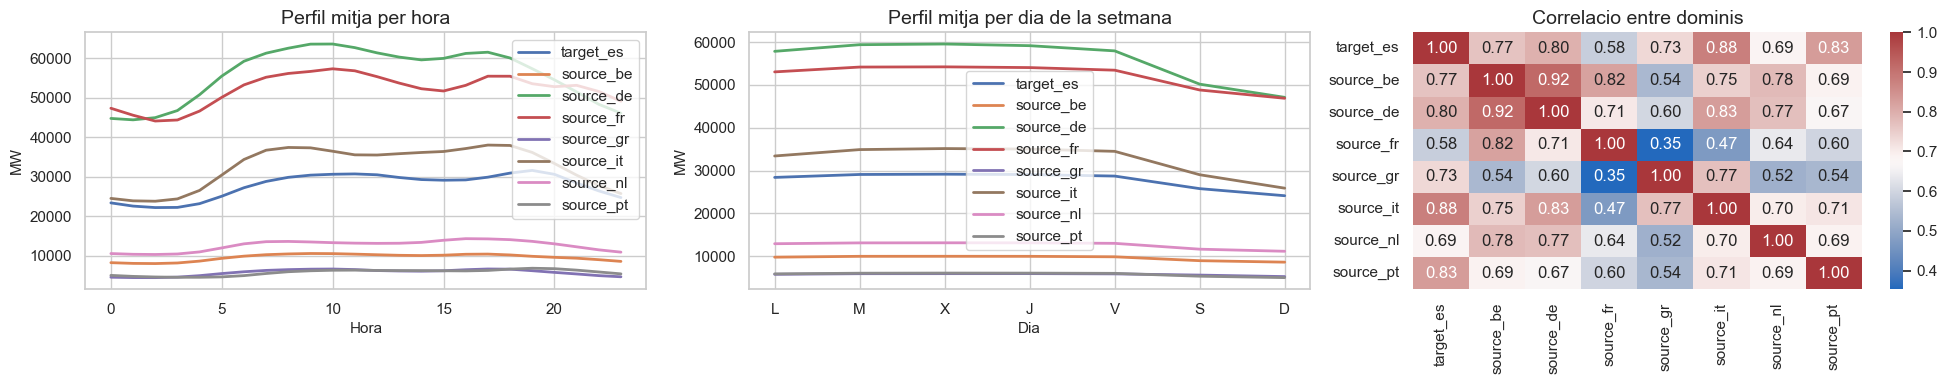

In [17]:
aligned_for_profiles = raw_demand.dropna().copy()
hourly_profile = aligned_for_profiles.groupby(aligned_for_profiles.index.hour).mean()
weekday_profile = aligned_for_profiles.groupby(aligned_for_profiles.index.dayofweek).mean()
corr_matrix = aligned_for_profiles.corr()

fig, axes = plt.subplots(1, 3, figsize=(20, 4))
hourly_profile.plot(ax=axes[0], linewidth=2)
axes[0].set_title("Perfil mitja per hora")
axes[0].set_xlabel("Hora")
axes[0].set_ylabel("MW")

weekday_profile.plot(ax=axes[1], linewidth=2)
axes[1].set_title("Perfil mitja per dia de la setmana")
axes[1].set_xlabel("Dia")
axes[1].set_ylabel("MW")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(["L", "M", "X", "J", "V", "S", "D"])

sns.heatmap(corr_matrix, cmap="vlag", annot=True, fmt=".2f", ax=axes[2])
axes[2].set_title("Correlacio entre dominis")
plt.tight_layout()
plt.show()

,country,correlation_with_es,mae_zscore,rmse_zscore,hourly_profile_distance,weekday_profile_distance
0,IT,0.879359,0.378764,0.491201,26462.639885,13303.124628
1,PT,0.831218,0.451522,0.581000,108445.472795,58335.905495
2,DE,0.797635,0.508521,0.636180,139370.502864,74795.986132
3,BE,0.765243,0.532132,0.685207,89768.221861,48210.831478
4,GR,0.733656,0.563105,0.729851,108493.140302,58400.473206
5,NL,0.686134,0.602544,0.792292,74988.543212,40267.315080
6,FR,0.583902,0.730409,0.912243,119433.017402,64420.684905


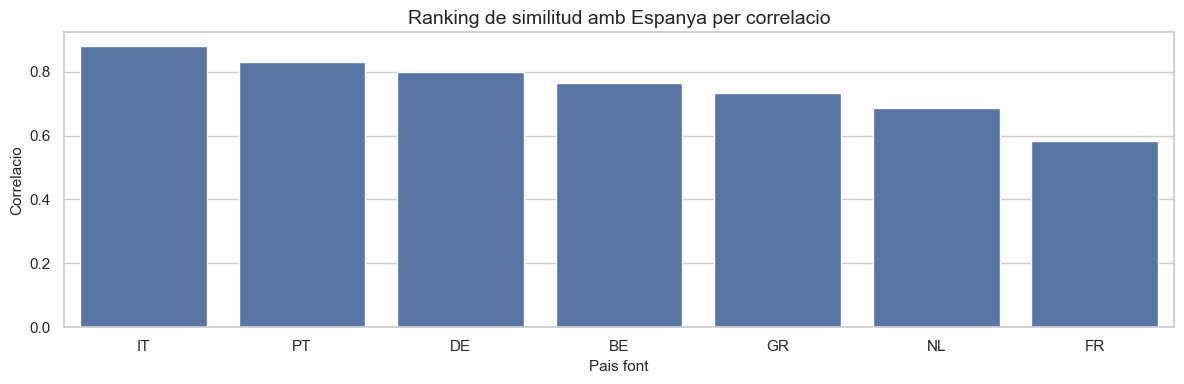

In [18]:
target_aligned = aligned_for_profiles["target_es"]
target_z = (target_aligned - target_aligned.mean()) / target_aligned.std()
target_hour_profile = hourly_profile["target_es"]
target_week_profile = weekday_profile["target_es"]

similarity_rows = []
for code in SOURCE_CODES:
    col = rename_series(code)
    source = aligned_for_profiles[col]
    source_z = (source - source.mean()) / source.std()
    hourly_distance = np.linalg.norm(hourly_profile[col] - target_hour_profile)
    weekday_distance = np.linalg.norm(weekday_profile[col] - target_week_profile)
    similarity_rows.append({
        "country": code,
        "correlation_with_es": target_aligned.corr(source),
        "mae_zscore": np.mean(np.abs(target_z - source_z)),
        "rmse_zscore": np.sqrt(np.mean((target_z - source_z) ** 2)),
        "hourly_profile_distance": hourly_distance,
        "weekday_profile_distance": weekday_distance,
    })

similarity_df = pd.DataFrame(similarity_rows)
similarity_df = similarity_df.sort_values(["correlation_with_es", "mae_zscore"], ascending=[False, True]).reset_index(drop=True)
display(similarity_df)

plt.figure(figsize=(12, 4))
sns.barplot(data=similarity_df, x="country", y="correlation_with_es", color="#4c72b0")
plt.title("Ranking de similitud amb Espanya per correlacio")
plt.ylabel("Correlacio")
plt.xlabel("Pais font")
plt.tight_layout()
plt.show()

## Preparacio per a domain adaptation

In [ ]:
common_start = max(frame.index.min() for frame in demand_frames.values())
common_end = min(frame.index.max() for frame in demand_frames.values())
es_reference = demand_frames[TARGET_CODE].loc[common_start:common_end].index

readiness_rows = []
for code in SOURCE_CODES:
    col = rename_series(code)
    aligned = demand_frames[code].reindex(es_reference)
    residual_missing = aligned[col].isna().mean()
    metrics = similarity_df.loc[similarity_df["country"] == code].iloc[0]
    readiness_rows.append({
        "country": code,
        "included": True,
        "coverage_on_es_timeline": round(1 - residual_missing, 6),
        "missing_residual": round(residual_missing, 6),
        "correlation_with_es": round(metrics["correlation_with_es"], 4),
        "mae_zscore": round(metrics["mae_zscore"], 4),
    })

readiness_df = pd.DataFrame(readiness_rows).sort_values("correlation_with_es", ascending=False).reset_index(drop=True)
display(readiness_df)


,country,included,coverage_on_es_timeline,missing_residual,correlation_with_es,mae_zscore
0,IT,True,1.000000,0.000000,0.8794,0.3788
1,PT,True,1.000000,0.000000,0.8312,0.4515
2,DE,True,1.000000,0.000000,0.7976,0.5085
3,BE,True,1.000000,0.000000,0.7652,0.5321
4,GR,True,0.999643,0.000357,0.7337,0.5631
5,NL,True,1.000000,0.000000,0.6861,0.6025
6,FR,True,0.998806,0.001194,0.5839,0.7304


Conclusio operativa: fer servir demanda-only com a baseline de domain adaptation amb Espanya com a domini objectiu.


## Preprocessing executable

In [ ]:
overlap_start = max(frame.index.min() for frame in demand_frames.values())
overlap_end = min(frame.index.max() for frame in demand_frames.values())
es_overlap = demand_frames[TARGET_CODE].loc[overlap_start:overlap_end].copy()
es_timeline = pd.date_range(start=es_overlap.index.min(), end=es_overlap.index.max(), freq="h", tz="UTC")

aligned_frames = []
for code in ALL_CODES:
    frame = demand_frames[code].loc[overlap_start:overlap_end].copy()
    frame = frame.reindex(es_timeline)
    frame = frame.interpolate(method="time", limit=3, limit_area="inside")
    aligned_frames.append(frame)

df_model = pd.concat(aligned_frames, axis=1)
df_model = df_model.dropna().copy()
df_model.index.name = "utc_timestamp"

df_model["hour_sin"] = np.sin(2 * np.pi * df_model.index.hour / 24)
df_model["hour_cos"] = np.cos(2 * np.pi * df_model.index.hour / 24)
df_model["dow_sin"] = np.sin(2 * np.pi * df_model.index.dayofweek / 7)
df_model["dow_cos"] = np.cos(2 * np.pi * df_model.index.dayofweek / 7)
df_model["month_sin"] = np.sin(2 * np.pi * (df_model.index.month - 1) / 12)
df_model["month_cos"] = np.cos(2 * np.pi * (df_model.index.month - 1) / 12)
df_model["is_weekend"] = (df_model.index.dayofweek >= 5).astype(int)

assert not df_model.index.duplicated().any()
assert df_model.index.tz is not None
assert df_model.isna().sum().sum() == 0
assert "target_es" in df_model.columns
assert {rename_series(code) for code in SOURCE_CODES}.issubset(df_model.columns)

display(df_model.head())

In [ ]:
train_df = df_model.loc[(df_model.index >= "2015-01-01") & (df_model.index <= "2022-12-31 23:00:00+00:00")].copy()
val_df = df_model.loc[(df_model.index >= "2023-01-01") & (df_model.index <= "2023-12-31 23:00:00+00:00")].copy()
test_df = df_model.loc[df_model.index >= "2024-01-01"].copy()

split_summary = pd.DataFrame([
    {"split": "train", "rows": len(train_df), "start": train_df.index.min(), "end": train_df.index.max()},
    {"split": "validation", "rows": len(val_df), "start": val_df.index.min(), "end": val_df.index.max()},
    {"split": "test", "rows": len(test_df), "start": test_df.index.min(), "end": test_df.index.max()},
])

display(split_summary)
print(f"Periode final: {df_model.index.min()} -> {df_model.index.max()}")
print(f"Nombre de files: {len(df_model)}")
print(f"Columnes finals ({len(df_model.columns)}): {list(df_model.columns)}")
print(f"Mides train/val/test: {len(train_df)} / {len(val_df)} / {len(test_df)}")